In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
class Value:
    
    # We are going to want to keep the information about how each Value was created in an expression / computation graph
    # I think the reason for this is this will be the information that backpropagation uses to compute gradients
    # backpropogration is the recursive application of the chain rule backwards through the computation graph\
    # I've learned how to do gradient descent in CS 357 but I believe we just let numpy compute the gradient for us.
    # So backprop is simply calculating the gradient, which is needed in grad descent. 
    # I also believe that it "analytically" computes the gradient with the expression graph rather than numerically approximating it

    def __init__(self, data, _children=(), _op='', label=''): # I don't know what self is (maybe a pointer to the object itself? data is the number I pass)
        self.data = data
        self.grad = 0.0 # initialize gradient dL/d(self.data)
        self._backward = lambda: None # So the backward function will set the partiial gradients of the nodes that created this node (default None is for operation nodes)
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"
    
    def __add__(self, other): # a + b is internally called by python as a.__add__(b)
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+') # self.data is a python FP number so this + is default python addition
        
        def _backward():
            self.grad += 1.0 * out.grad # this reduces to below for the single use case because they are initialized to zero
            other.grad += 1.0 * out.grad
            
            # Below was the gradient calculation that works when the same variable is not used multiple times in the computation graph
            # But if the same variable is used multiple times, like a + a, then this code overwrites the gradient because self = other
            # The solution is given by the multivariable chain rule
            
            # d(out) / d(self) = 1
            # d(out) / d(other) = 1
            # self.grad = dL/d(self) = dL/d(out) * d(out)/d(self) = out.grad * 1
            # other.grad = dL/d(other) = dL/d(out) * d(out)/d(other) = out.grad * 1
            # self.grad = 1.0 * out.grad
            # other.grad = 1.0 * out.grad
            
        out._backward = _backward
        
        return out
    
    def __radd__(self, other): # other + self. Not included in lecture. I'm also still confused by how these roperations work
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # so we can do a * 2
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            
        out._backward = _backward
        return out
    
    def __pow__(self, other): # self ** other
        assert isinstance(other, (int, float)), "only supporting int/float type powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        
        def _backward():
            self.grad += (other * self.data**(other - 1)) * out.grad
        out._backward = _backward
        
        return out
        
        
    def __rmul__(self, other): # other * self
        # so we can do 2 * a. If python can't compute self * other = self.__mul__(other) in mul, it falls back to self.__rmul__(other)
        return self * other # wait but this didn't swap the order? Did it?
    
    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)
    
    def __rsub__(self, other): # other - self . Not in lecture
        return other + (-self)

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(t, (self,), 'tanh')
        # dtanh/dn = 1 - tanh^2(n) is dt/dn = 1-t^2
        def _backward():
            self.grad += (1 - t**2) * out.grad # the functionality of _backward is always to calculate children.grad wrt out and multiply by out.grad. recall out is the produce of the operation that children created
        out._backward = _backward
        
        return out
    
    def exp(self):
        n = self.data
        out = Value(math.exp(n), (self,), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad # d(exp(n))/dn = exp(n) = out.data
        out._backward = _backward
        
        return out
    
    def backward(self): # Back Propagation Algorithm
        # Topological Sort is a way of laying out a graph such that all edges go only from left to right. Defined recursively.
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child) # recursive step
                topo.append(v) # only adds this node to the list after all children have been added, guaranteeing proper ordering
        build_topo(self)
        
        self.grad = 1.0 # d(self)/d(self) = 1
        for node in reversed(topo):
            node._backward()



In [3]:
# Want to visualize expression graphs
# So this graph visualizes the output of the "forward pass"

from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in the graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child) # recursive step
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={ 'rankdir': 'LR' }) # LR means left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record) node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid+ n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

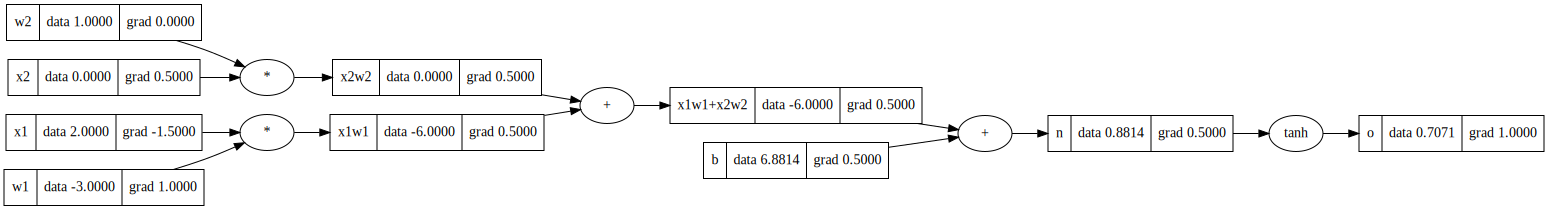

In [4]:
# This is a single neuron

# inputs (data)
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1+x2w2'
n = x1w1x2w2 + b; n.label = 'n'

# n is the cell body raw activation, without the activation function applied yet
# We will use tanh as the activation function. Sigmoid function is another common activation function. Just want a "squashing function"?

o = n.tanh(); o.label = 'o' # output of neuron after activation function
o.backward()
draw_dot(o)
# Remember that my activation function is different than my loss function

# I believe we are most interested in do/dw1 and do/dw2?


$$
\frac{dL}{dw_i} = \frac{dL}{dy_1}\frac{dy_1}{dy_2}\cdots\frac{dy_{n-1}}{dw_{i}}
$$

$$
\frac{dz}{dt} = \sum_{i=1}^{n} \left( \frac{\partial z}{\partial x_i} \frac{dx_i}{dt} \right)
$$

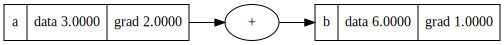

In [5]:
# Multiple use of same variable test

# There are really two edges going into the addition node
# Because we now accumulate variables, all contributions to the gradient will be summed correctly
# Not really sure if this is actually the multivarite chain rule formally 
#       or just a coding trick to ensure that we are properly getting the single variable gradients. But really a is the same variable, written down twice.
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

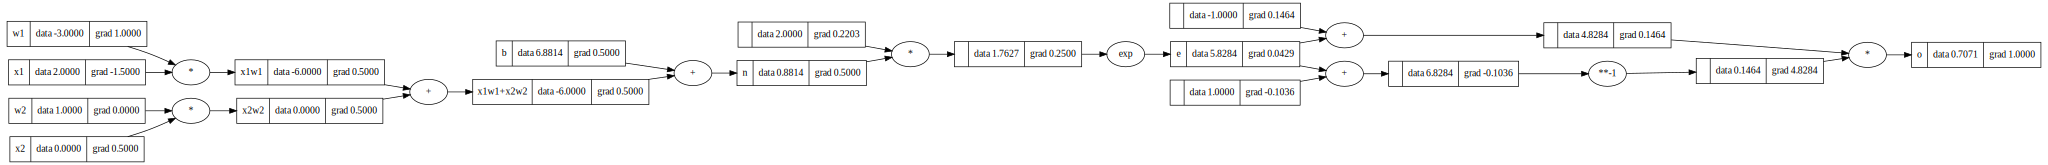

In [6]:
# inputs (data)
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1+x2w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2 * n).exp(); e.label = 'e'
o = (e - 1) / (e + 1); o.label = 'o'

o.backward()
draw_dot(o)

In [7]:
import torch

In [8]:
# We now do the same thign as above with PyTorch
# PyTorch uses tensors which are just n-dimensional arrays of scalars
# multigrad is a scalar valued engine

#x1 = torch.tensor(2.0, dtype=torch.float64, requires_grad=True) is the more modern syntax but there are some real differences
x1 = torch.Tensor([2.0]).double()                     ; x1.requires_grad_(True) # Why would leaf nodes default to not wanting a gradient?
x2 = torch.Tensor([0.0]).double()                     ; x2.requires_grad_(True)
w1 = torch.Tensor([-3.0]).double()                    ; w1.requires_grad_(True)
w2 = torch.Tensor([1.0]).double()                     ; w2.requires_grad_(True)
b  = torch.Tensor([6.8813735870195432]).double()      ; b.requires_grad_(True)
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item()) # same as o.item() i think
o.backward()

0.7071066904050358


In [29]:
# Neuron class matching PyTorch API
import random

class Neuron:

    def __init__(self, nin): # nin is number of inputs to this neuron
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)] # weight for each input
        self.b = Value(random.uniform(-1,1)) # bias
    
    def __call__(self, x):
        # w * x + b
        # zip takes two iterators and creates a new iterator that iterates of the tuples of corresponding entries (by index)
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
        
class Layer:
    
    def __init__(self, nin, nout): # nout is number of neurons in this layer (number of outputs in this layer) - but not necessarily one out edge per neuron?
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs


class MLP: # multi-layer perceptron
    
    def __init__(self, nin, nouts): 
        # nin is number of inputs
        # nouts is a list of nout (for each Layer initializer) - this list defines the size of each layer
        sz = [nin] + nouts # ? 
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
        
#x = [2.0, 3.0]
#n = Layer(2, 3) # three 2-dimensional neurons
#n(x)

x = [2.0, 3.0, -5.0]
n = MLP(3, [4, 4, 1]) # 3 inputs into 2 layers of 4 neurons, and then 1 output
n(x) # so this is the forward pass on the MLP
# forward pass on an MLP means we are evaluating the value of the MLP called on the data x


Value(data=-0.7667127298693536, label=)

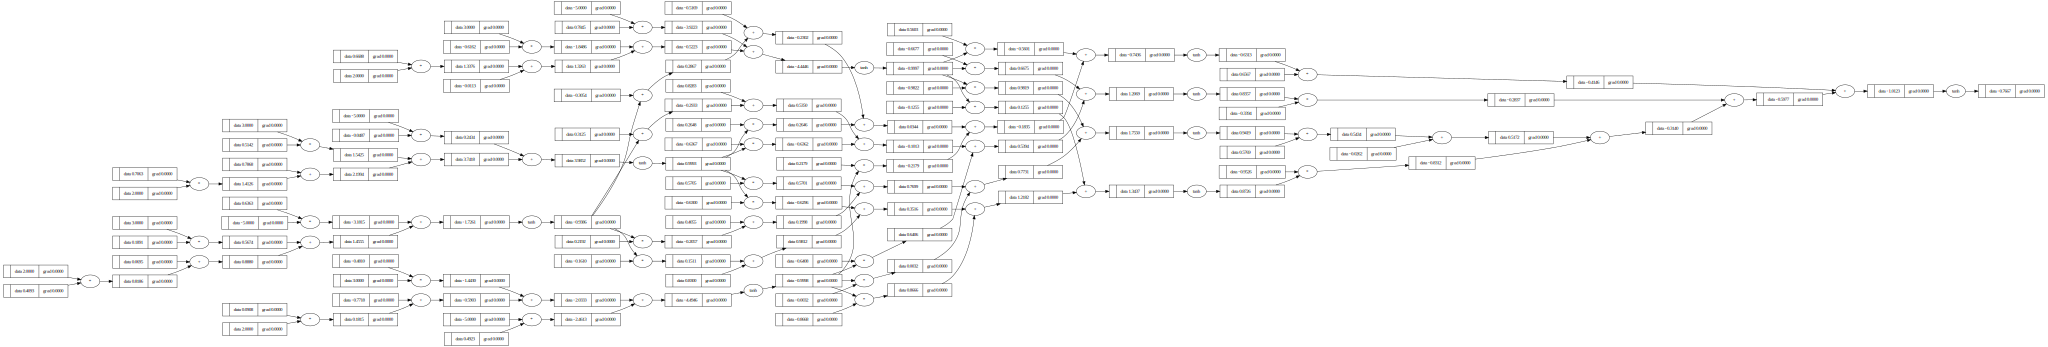

In [30]:
draw_dot(n(x))

In [31]:
# Example dataset

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0] # desired outputs
# so we want n(xs[i]) = ys[i]
# so this is a simple binary classifier neural net
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.7895717436551706, label=),
 Value(data=0.43870922383047023, label=),
 Value(data=-0.5543866608841245, label=),
 Value(data=-0.7576699047837888, label=)]

In [37]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) # mean squared error loss
loss.data

8.560425998604535

In [38]:
loss.backward()

In [39]:
n.layers[0].neurons[0].w[0].grad

0.06734486809751508

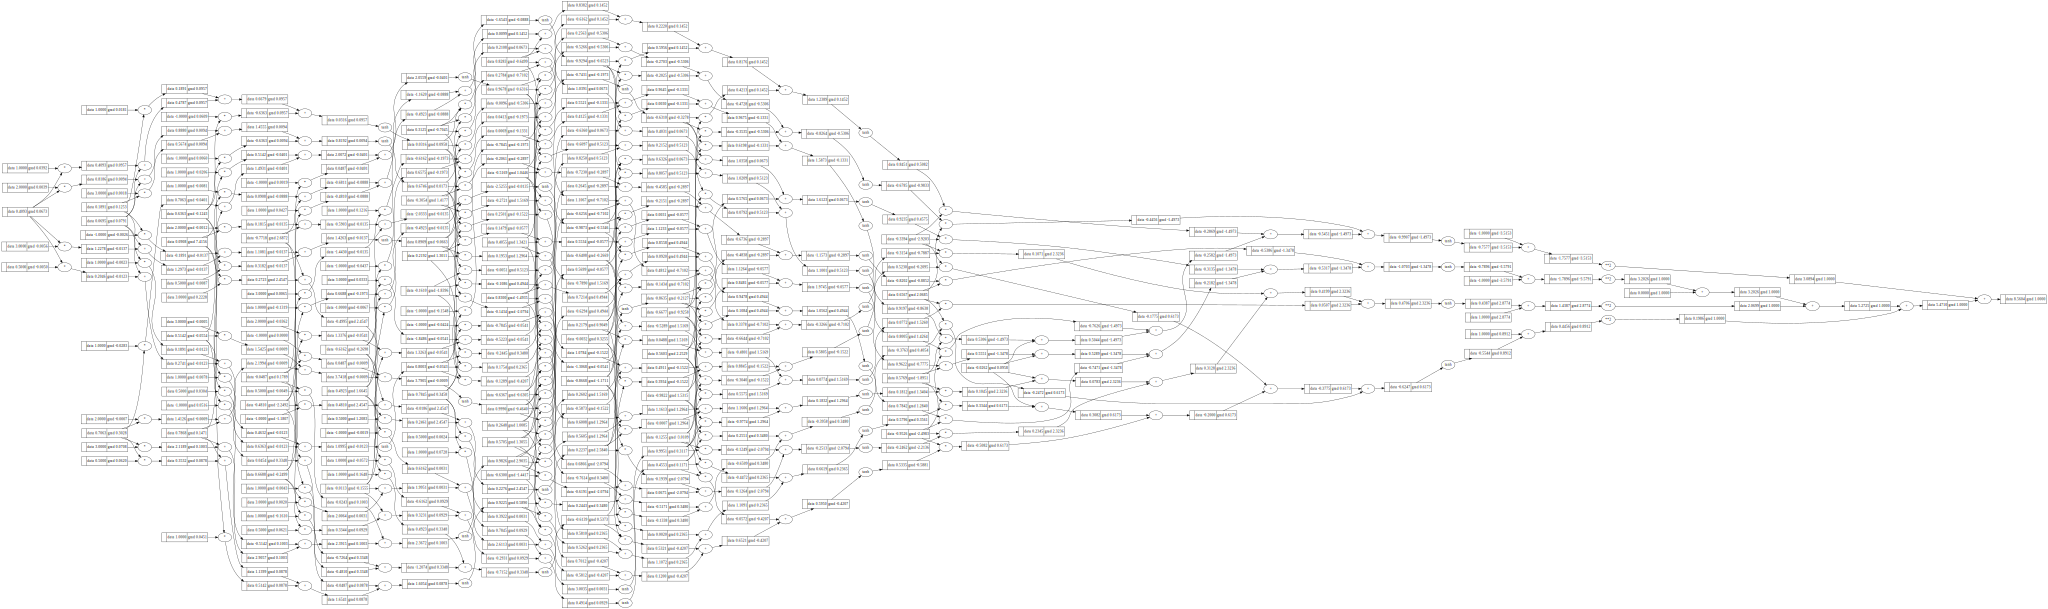

In [40]:
draw_dot(loss)